<sub>Mario Stanke, Felix Becker, University of Greifswald, Germany</sub>
# A Simple Regression Neural Network

This notebook gives the first example of a neural network in action. To keep it simple we estimate data simulated from a univariate function.

## Generate an Artificial Dataset

In [1]:
# import libraries
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
def f(x):
    '''A simple one-dimensional function with a few extrema'''
    return np.sin(15 * x) + 9 * x - 9 * x**2

#### Simulate $(x, y)$ pairs as artificial data set

In [3]:
np.random.seed(1)
m = 100 # number of data points (examples)
x = np.linspace(0, 1, m) # equidistant in [0,1] (both boundaries included)
y_theoretical = f(x)     # the points on the curve 
sigma = 0.2
y = y_theoretical + sigma * np.random.randn(m) # observations have noise (normal with mean 0 and variance 0.01)

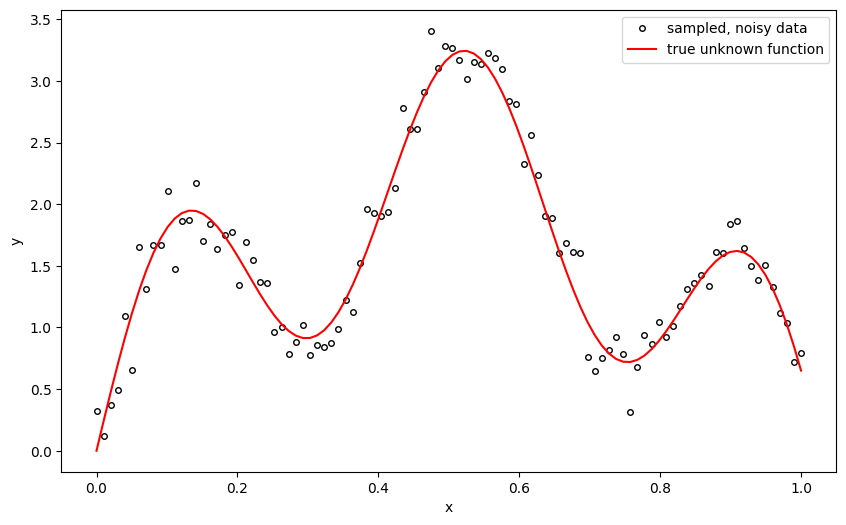

In [4]:
def plot_curve():
    fig, ax = plt.subplots(figsize = (10, 6))
    ax.plot(x, y, 'ko', fillstyle = 'none', markersize = 4, label = "sampled, noisy data") # ko: blac(k) circle
    ax.plot(x, y_theoretical, 'r', label = "true unknown function")
    plt.xlabel("x")
    plt.ylabel("y")
    return ax

ax = plot_curve()
ax.legend();

## Create Neural Network Model  
We will use [`torch.nn`](https://pytorch.org/docs/stable/nn.html), a high-level approach to neural network design and learning. The NN shall have 2 hidden layers with 8 neurons each. As activation functions we chose the logistic sigmoid function.

<img src="nn8-8.png" alt="network architecture" width="500"/>

In [5]:
torch.manual_seed(1)  # so we all get the same pseudorandom results

# a neural network is a stack of layers, in PyTorch called "Sequential" model
model = nn.Sequential(
    nn.Linear(1, 8),   # fully connected layer: 1 input, 8 outputs (+ 8 bias parameters)
    nn.Sigmoid(),      # activation function applied element-wise
    nn.Linear(8, 8),   # 8 inputs, 8 outputs (+ 8 bias parameters)
    nn.Sigmoid(),
    nn.Linear(8, 1),   # 8 inputs, 1 output (+ 1 bias parameter)
)

print(model)          # summarizes layers and parameters
print("Total parameters:", sum(p.numel() for p in model.parameters()))
print("\nInitial weights (a look under the hood):")
for name, param in model.named_parameters():
    print(f"  {name}: {param.data}")

Sequential(
  (0): Linear(in_features=1, out_features=8, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=8, out_features=8, bias=True)
  (3): Sigmoid()
  (4): Linear(in_features=8, out_features=1, bias=True)
)
Total parameters: 97

Initial weights (a look under the hood):
  0.weight: tensor([[ 0.5153],
        [-0.4414],
        [-0.1939],
        [ 0.4694],
        [-0.9414],
        [ 0.5997],
        [-0.2057],
        [ 0.5087]])
  0.bias: tensor([ 0.1390, -0.1224,  0.2774,  0.0493,  0.3652, -0.3897, -0.0729, -0.0900])
  2.weight: tensor([[ 0.0512, -0.0014,  0.3091,  0.1100, -0.1317, -0.2135, -0.0593, -0.1525],
        [-0.1133,  0.0169,  0.2108,  0.1922, -0.3456,  0.2192,  0.0988,  0.3354],
        [ 0.2334, -0.3221, -0.3362, -0.1705,  0.3105, -0.0589,  0.1513, -0.1643],
        [ 0.3469, -0.1496,  0.2651,  0.0042, -0.1863,  0.1817, -0.1877,  0.1040],
        [-0.1021, -0.0388, -0.3399, -0.1686,  0.1919, -0.0859,  0.3522,  0.2834],
        [-0.0166, -0.2360,  0.2153,  0.1097

The weights are randomly initializated. This is important (why?) as can be the parameters of the distribution. We postpone parameter initialization to the next notebook.

### Compile the model

In [6]:
# define the loss function and optimization algorithm
loss_fn = nn.MSELoss()                                  # mean squared error
optimizer = optim.Adam(model.parameters(), lr=0.1)      # Adam is a popular variant of SGD

# convert data to PyTorch tensors (column vectors)
x_tensor = torch.tensor(x, dtype=torch.float32).reshape(-1, 1)
y_tensor = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

### Train the parameters (learning)

In [7]:
# execute the actual training
epochs = 2000
loss_history = []

for epoch in range(epochs):
    optimizer.zero_grad()              # reset gradients
    y_pred = model(x_tensor)          # forward pass
    loss = loss_fn(y_pred, y_tensor)  # compute loss
    loss.backward()                   # compute gradients
    optimizer.step()                  # update parameters
    loss_history.append(loss.item())
# verbose=True gives more output; omitted here to keep output clean

### Examine the learning progress

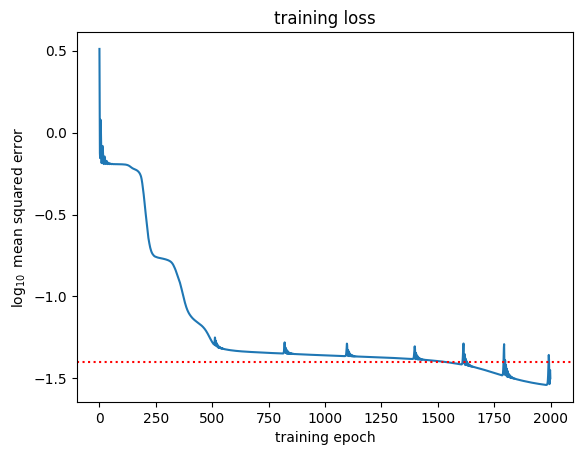

In [8]:
plt.plot(np.log10(loss_history))  # one mse value per epoch
plt.title("training loss")
plt.xlabel("training epoch")
plt.ylabel(r"$\log_{10}$ mean squared error")
plt.axhline(y=np.log10(sigma**2), color="red", linestyle=":");

Observe that with our choice for the measurement noise the theoretical optimum for the mean squared error *on new data* is $10^{-2}$ (red dotted line).
### Use the model for predictions

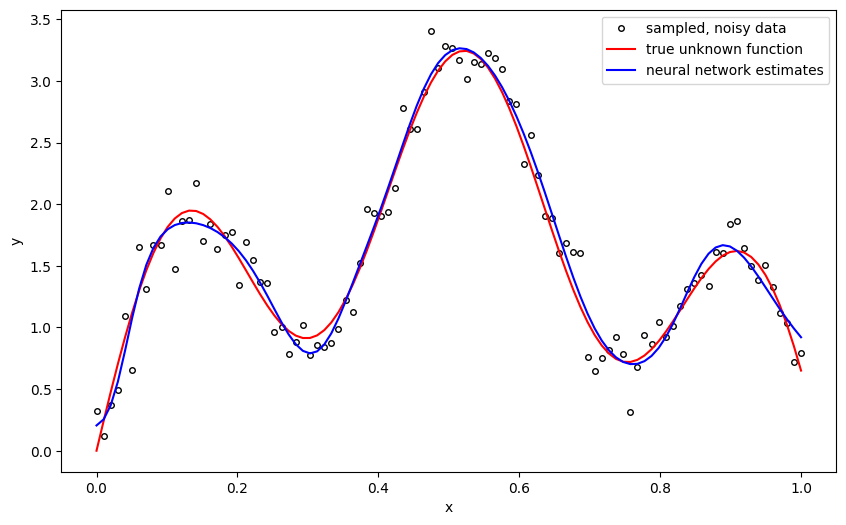

In [9]:
with torch.no_grad():  # disable gradient computation for inference
    y_pred = model(x_tensor).numpy()

ax = plot_curve()
ax.plot(x, y_pred, 'b', label="neural network estimates")  # (b)lue
ax.legend();

To summarize, we did:
- start with data points $x$ and corresponding observations $y$
- created a simple neural network using PyTorch by stacking layers
- selected optimizer, learning rate and error function from a pool of standard choices
- fitted the model to the data and visualized the result